# **Sobre o conjunto de dados**

Os dados foram retirados do conjunto de dados original do desafio Netflix para recomendações de ofertas. Ao todo são mais de 26 Milhões de registros, o que dificulta o manuseio e trabalho com os dados. Mesmo no colab temos algumas didifucldades de uso destes dados, devido ao tamanho do conjunto de dados.

Recomendo que utilizem uma amostra dos dados usando df = pd.read_csv('Netflix_df_full.csv', rows=50000). Com este codigo usaremos apenas 50 Mil registros.



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


#Bibliotecas para google drive
from pydrive.auth import GoogleAuth
from pydrive.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials
import statsmodels.api as sm

auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

In [ ]:
# Baixa os dados de treinamento
link = 'https://drive.google.com/file/d/1PaaC_T63eFbQIT7YwWisULZPHopgppCY/view?usp=share_link'
id = link.split("/")[-2]
downloaded = drive.CreateFile({'id':id})
downloaded.GetContentFile('Netflix_df_full.csv')
df = pd.read_csv('/content/Netflix_df_full.csv', nrows=100000)
df.shape

(100000, 8)

In [ ]:
#df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Regras de associação/Netflix_df_full.csv', nrows=50000)

In [ ]:
df.shape # Checando quantidade de colunas e registros

(100000, 8)

In [ ]:
df.sample(3)

,Unnamed: 0,Movie_Id,Customer_Id,Rating,Date,ReleaseYear,MovieName,_merge
99329,99329,13389,147389,4,2002-02-12,1982,The World According to Garp,both
56647,56647,13384,2189299,4,2004-05-10,1979,Kramer vs. Kramer,both
99165,99165,13389,1345167,5,2002-01-05,1982,The World According to Garp,both


In [ ]:
df.drop('_merge', axis=1)
df.drop('Unnamed: 0', axis=1)

,Movie_Id,Customer_Id,Rating,Date,ReleaseYear,MovieName,_merge
0,13368,2385003,4,2004-07-08,1999,Sarfarosh,both
1,13368,659432,3,2005-03-16,1999,Sarfarosh,both
2,13368,751812,2,2002-12-16,1999,Sarfarosh,both
3,13368,2625420,2,2004-05-25,1999,Sarfarosh,both
4,13368,1650301,1,2005-08-30,1999,Sarfarosh,both
...,...,...,...,...,...,...,...
99995,13389,39686,5,2005-08-26,1982,The World According to Garp,both
99996,13389,36629,4,2004-03-03,1982,The World According to Garp,both
99997,13389,958634,3,2003-11-20,1982,The World According to Garp,both
99998,13389,151871,4,2004-01-22,1982,The World According to Garp,both


In [ ]:
df.describe() # Estatísticas do dataset

,Unnamed: 0,Movie_Id,Customer_Id,Rating,ReleaseYear
count,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000
mean,49999.500000,13382.559310,1.321000e+06,3.661340,1974.309260
std,28867.657797,4.408045,7.650507e+05,1.004669,19.437493
min,0.000000,13368.000000,6.000000e+00,1.000000,1933.000000
25%,24999.750000,13379.000000,6.586010e+05,3.000000,1960.000000
50%,49999.500000,13384.000000,1.316708e+06,4.000000,1979.000000
75%,74999.250000,13384.000000,1.984458e+06,4.000000,1982.000000
max,99999.000000,13389.000000,2.649388e+06,5.000000,2004.000000


In [ ]:
df.duplicated().sum() # Checando se há dados duplicados

0

In [ ]:
# Checa se dentre as colunas do dataset há quantidade de dados faltando maiores que zero
vars_with_na = [var for var in df.columns if df[var].isnull().sum() > 0]
df[vars_with_na].isnull().mean()

Series([], dtype: float64)

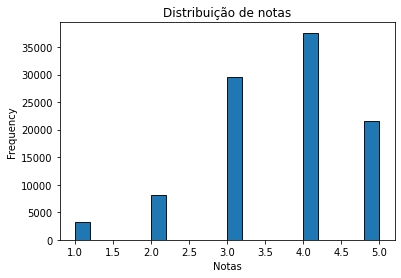

In [ ]:
# Vamos observar a distribuição das notas
plt.hist(df["Rating"], 20, lw = 0.89, ec = 'black')
plt.xlabel('Notas')
plt.ylabel('Frequency')
plt.title('Distribuição de notas')
plt.show()

In [ ]:
# Vamos observar quais são os filmes com maior representatividade
df["MovieName"].value_counts()

Kramer vs. Kramer                            37884
His Girl Friday                              16553
The World According to Garp                  10696
If These Walls Could Talk 2                   7602
Breathless                                    6965
The Mosquito Coast                            6774
Justice League: Paradise Lost                 2715
Kim Possible: A Sitch in Time                 2044
Stray Dog                                     1776
Prey for Rock and Roll                        1511
Andy Griffith Show: Classic Favorites         1157
Winter Light                                  1048
Dinner at Eight                                854
Sarfarosh                                      527
Reign: The Conqueror                           389
Code Hunter                                    358
Berga: Soldiers of Another War                 286
Duran Duran: Sing Blue Silver                  249
Dandelion Dead                                 230
PRIDE Fighting Championships: C

# **Recomendações baseadas em popularidade**

Esta abordagem sugere usarmos a popularidade dos titulos, titulos mais votados e criamos um top 10 por exemplo para recomendarmos.

In [ ]:
# Selecionamos os titulos com mais de 5000 avaliações.
df_new = df.groupby("MovieName").filter(lambda x: x['Rating'].count()>= 5000)
df_new.shape

(86474, 8)

In [ ]:
# Criamos um novo dataset com os titulos com a média das avaliações
df_ratings = pd.DataFrame(df_new.groupby('MovieName').Rating.mean())

In [ ]:
# Adicionamos uma coluna com a quantidade de avaliações
df_ratings['Rating_counts'] = df_new.groupby('MovieName').Rating.count()

In [ ]:
# Agora ordenamos o top  titulos pela quantidade de avaliações
df_ratings.sort_values(by = 'Rating_counts', ascending = False).head(10)

,Rating,Rating_counts
MovieName,,
Kramer vs. Kramer,3.705707,37884
His Girl Friday,3.898387,16553
The World According to Garp,3.573859,10696
If These Walls Could Talk 2,3.599053,7602
Breathless,3.627710,6965
The Mosquito Coast,3.172867,6774


In [ ]:
global_media = df_ratings['Rating'].mean() # Média Global de avaliações
lim_inf = df_ratings.Rating_counts.min() # Limite minimo para estar na recomendação

# Função de média ponderada
def weighted_rating (x, m = lim_inf, C = global_media):
    v = x['Rating_counts']
    R = x['Rating']
    return (v/(v + m) * R) + (m/(m+v) * C)

In [ ]:
df_ratings['score'] = df_ratings.apply(weighted_rating, axis=1) # adiciona uma coluna com a nota media ponderada de avaliações
df_ratings.sort_values(by='score', ascending=False).head(15) # Apresenta as top 15 Titulos mais populares

,Rating,Rating_counts,score
MovieName,,,
His Girl Friday,3.898387,16553,3.810653
Kramer vs. Kramer,3.705707,37884,3.689106
Breathless,3.627710,6965,3.612205
If These Walls Could Talk 2,3.599053,7602,3.597739
The World According to Garp,3.573859,10696,3.582547
The Mosquito Coast,3.172867,6774,3.384565


In [ ]:
df['ReleaseYear'].min(),df['ReleaseYear'].max()

(1933, 2004)

# **Filtragem Colaborativa**
Este é o tipo de recomendação item-item

In [ ]:
!pip install surprise

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 772.0/772.0 KB 31.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.3-cp38-cp38-linux_x86_64.whl size=3366459 sha256=764c616a27a0cd94468b9cfe88bc292b266181b9c0c57f149992de53af88046f
  Stored in directory: /root/.cache/pip/wheels/af/db/86/2c18183a80ba05da35bf0fb7417aac5cddbd93bcb1b92fd3ea
Successfully built scikit-surprise


In [ ]:
from surprise import KNNWithMeans
from surprise import Dataset
from surprise import accuracy
from surprise import Reader
import os
from surprise.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD

A Biblioteca Surprise precisa que os dados estejam no formato id_usuario, id_produto, rating e timestamp, por isso vamos deixar nosso dataset neste formato antes de submete-lo ao Surprise.

In [ ]:
cols = ['Customer_Id', 'MovieName', 'Rating']
df1 = df[cols]

In [ ]:
reader = Reader(line_format='user item rating')
dataset = Dataset.load_from_df(df1, reader=reader)

In [ ]:
train, test = train_test_split(dataset, test_size=0.3,random_state=10)

In [ ]:
# Para definir se o modelo será baseado em usuário ou item basta alterar user_based: False / True
rec_model = KNNWithMeans(k=5, sim_options={'user_based': False})
rec_model.fit(train)

Computing the msd similarity matrix...
Done computing similarity matrix.


In [ ]:
test_pred = rec_model.test(test)

In [ ]:
test_pred

In [ ]:
print("Item-based Model : Test Set")
accuracy.rmse(test_pred, verbose=True)

Item-based Model : Test Set
RMSE: 1.0513


1.0513089377408484

In [ ]:
rec_model.get_neighbors(1, 10)

[7, 19, 3, 14, 0, 6, 12, 2, 9, 15]

In [ ]:
df_ratings.iloc[[7, 19, 3, 14, 0, 6, 12, 2, 9, 15]].index

IndexError: ignored

## **Outras abordagens da Biblioteca Surprise**

**NormalPreditor** - Prevê uma classificação aleatória com base na distribuição do conjunto de treinamento.

**BaselineOnly** - Prevê uma estimativa de baseline para determinado usuário/item.

**KNNBasic** - Algoritmo básico de filtragem colaborativa.

**KNNWithMeans** - Algoritmo básico de filtragem colaborativa que considera as avaliações médias de cada usuário.

**KNNWithZScore** - Algoritmo básico de filtragem colaborativa que considera o Z-Score de cada usuário.

**KNNBaseline** - Algoritmo básico de filtragem colaborativa que leva em consideração uma classificação de baseline.

**SVD** - Algoritmo SVD é equivalente a Fatoração de Matriz Probabilística.

**SVDpp** - Algoritmo SVDpp é uma extensão do SVD que leva em consideração as classificações implícitas.

**NMF** - Algoritmo de filtragem colaborativa baseado em fatoração de matrizes não negativas, muito semelhante ao SVD.

**SlopeOne** - Algoritmo de filtragem colaborativa não trivial baseado em intem e suas avaliações.

**Co-Clustering** - Algoritmo de filtragem colaborativa baseado em co_clusterização (clusteriza linhas e colunas de forma simultânea)

# Market Basket Analysis


Market basket analysis (análise de cestas de compras) é considerada por muitos a mais simples das tarefas de data mining. Apesar disso, possui um enorme número de aplicações práticas, dentre elas a análise de padrões de compras, os sistemas de recomendação e a análise de logs de servidores Web. O objetivo da tarefa é identificar combinações de itens que ocorrem frequência significativa em bancos de dados. Este artigo apresenta e descreve as principais etapas envolvidas em processos práticos de market basket analysis.

É aqui que entram os algoritmos para market basket analysis (análise de cestas de compras). Trata-se de uma tecnologia especialmente criada com o objetivo de descobrir combinações de itens que ocorrem com frequência acima do esperado em uma base de dados. A partir das combinações de itens consideradas interessantes do ponto de vista estatístico, os algoritmos de market basket analysis geram um conjunto de regras de associação para os usuários. Para que a coisa não fique muito abstrata, o exemplo a seguir ilustra um padrão real que foi automaticamente descoberto por um algoritmo de market basket analysis.


In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

In [ ]:
df = pd.read_excel('http://archive.ics.uci.edu/ml/machine-learning-databases/00352/Online%20Retail.xlsx')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [ ]:
df['Description'] = df['Description'].str.strip()
df.dropna(axis=0, subset=['InvoiceNo'], inplace=True)
df['InvoiceNo'] = df['InvoiceNo'].astype('str')
df = df[~df['InvoiceNo'].str.contains('C')]

In [ ]:
basket = (df[df['Country'] =="France"]
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

In [ ]:
basket.sample(5)

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 EGG HOUSE PAINTED WOOD,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE WOODLAND,15CM CHRISTMAS GLASS BALL 20 LIGHTS,16 PIECE CUTLERY SET PANTRY DESIGN,18PC WOODEN CUTLERY SET DISPOSABLE,20 DOLLY PEGS RETROSPOT,200 RED + WHITE BENDY STRAWS,3 HOOK HANGER MAGIC GARDEN,3 PIECE SPACEBOY COOKIE CUTTER SET,3 RAFFIA RIBBONS 50'S CHRISTMAS,3 STRIPEY MICE FELTCRAFT,3 TIER CAKE TIN RED AND CREAM,3 TRADITIONAl BISCUIT CUTTERS SET,36 DOILIES DOLLY GIRL,36 DOILIES VINTAGE CHRISTMAS,36 FOIL HEART CAKE CASES,36 FOIL STAR CAKE CASES,36 PENCILS TUBE RED RETROSPOT,36 PENCILS TUBE SKULLS,36 PENCILS TUBE WOODLAND,3D DOG PICTURE PLAYING CARDS,3D HEARTS HONEYCOMB PAPER GARLAND,3D SHEET OF DOG STICKERS,3D TRADITIONAL CHRISTMAS STICKERS,3D VINTAGE CHRISTMAS STICKERS,4 IVORY DINNER CANDLES SILVER FLOCK,4 PINK DINNER CANDLE SILVER FLOCK,4 TRADITIONAL SPINNING TOPS,5 HOOK HANGER MAGIC TOADSTOOL,5 HOOK HANGER RED MAGIC TOADSTOOL,50'S CHRISTMAS GIFT BAG LARGE,6 GIFT TAGS 50'S CHRISTMAS,...,WOODLAND DESIGN COTTON TOTE BAG,WOODLAND LARGE BLUE FELT HEART,WOODLAND LARGE PINK FELT HEART,WOODLAND LARGE RED FELT HEART,WOODLAND MINI BACKPACK,WOODLAND PARTY BAG + STICKER SET,WOODLAND SMALL BLUE FELT HEART,WOODLAND SMALL PINK FELT HEART,WOODLAND SMALL RED FELT HEART,WOODLAND STORAGE BOX LARGE,WOODLAND STORAGE BOX SMALL,WORLD WAR 2 GLIDERS ASSTD DESIGNS,WRAP VINTAGE DOILY,WRAP 50'S CHRISTMAS,WRAP ALPHABET DESIGN,WRAP CAROUSEL,WRAP CHRISTMAS VILLAGE,WRAP CIRCUS PARADE,WRAP DOILEY DESIGN,WRAP DOLLY GIRL,WRAP ENGLISH ROSE,WRAP GINGHAM ROSE,WRAP GREEN PEARS,WRAP I LOVE LONDON,WRAP PAISLEY PARK,WRAP PINK FAIRY CAKES,WRAP POPPIES DESIGN,WRAP RED APPLES,WRAP RED VINTAGE DOILY,WRAP SUKI AND FRIENDS,WRAP VINTAGE PETALS DESIGN,YELLOW COAT RACK PARIS FASHION,YELLOW GIANT GARDEN THERMOMETER,YELLOW SHARK HELICOPTER,ZINC STAR T-LIGHT HOLDER,ZINC FOLKART SLEIGH BELLS,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL
InvoiceNo,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
567657,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
570267,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
574501,0.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
557295,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
567618,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,25.0,25.0,25.0,0.0,0.0,0.0,50.0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
def encode_units(x):
    if x <= 0:
        return 0
    if x >= 1:
        return 1

basket_sets = basket.applymap(encode_units)
basket_sets.drop('POSTAGE', inplace=True, axis=1)

In [ ]:
basket_sets.sample(3)

Description,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 EGG HOUSE PAINTED WOOD,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,12 PENCILS SMALL TUBE RED RETROSPOT,12 PENCILS SMALL TUBE SKULL,12 PENCILS TALL TUBE POSY,12 PENCILS TALL TUBE RED RETROSPOT,12 PENCILS TALL TUBE WOODLAND,15CM CHRISTMAS GLASS BALL 20 LIGHTS,16 PIECE CUTLERY SET PANTRY DESIGN,18PC WOODEN CUTLERY SET DISPOSABLE,20 DOLLY PEGS RETROSPOT,200 RED + WHITE BENDY STRAWS,3 HOOK HANGER MAGIC GARDEN,3 PIECE SPACEBOY COOKIE CUTTER SET,3 RAFFIA RIBBONS 50'S CHRISTMAS,3 STRIPEY MICE FELTCRAFT,3 TIER CAKE TIN RED AND CREAM,3 TRADITIONAl BISCUIT CUTTERS SET,36 DOILIES DOLLY GIRL,36 DOILIES VINTAGE CHRISTMAS,36 FOIL HEART CAKE CASES,36 FOIL STAR CAKE CASES,36 PENCILS TUBE RED RETROSPOT,36 PENCILS TUBE SKULLS,36 PENCILS TUBE WOODLAND,3D DOG PICTURE PLAYING CARDS,3D HEARTS HONEYCOMB PAPER GARLAND,3D SHEET OF DOG STICKERS,3D TRADITIONAL CHRISTMAS STICKERS,3D VINTAGE CHRISTMAS STICKERS,4 IVORY DINNER CANDLES SILVER FLOCK,4 PINK DINNER CANDLE SILVER FLOCK,4 TRADITIONAL SPINNING TOPS,5 HOOK HANGER MAGIC TOADSTOOL,5 HOOK HANGER RED MAGIC TOADSTOOL,50'S CHRISTMAS GIFT BAG LARGE,6 GIFT TAGS 50'S CHRISTMAS,...,WOODLAND DESIGN COTTON TOTE BAG,WOODLAND LARGE BLUE FELT HEART,WOODLAND LARGE PINK FELT HEART,WOODLAND LARGE RED FELT HEART,WOODLAND MINI BACKPACK,WOODLAND PARTY BAG + STICKER SET,WOODLAND SMALL BLUE FELT HEART,WOODLAND SMALL PINK FELT HEART,WOODLAND SMALL RED FELT HEART,WOODLAND STORAGE BOX LARGE,WOODLAND STORAGE BOX SMALL,WORLD WAR 2 GLIDERS ASSTD DESIGNS,WRAP VINTAGE DOILY,WRAP 50'S CHRISTMAS,WRAP ALPHABET DESIGN,WRAP CAROUSEL,WRAP CHRISTMAS VILLAGE,WRAP CIRCUS PARADE,WRAP DOILEY DESIGN,WRAP DOLLY GIRL,WRAP ENGLISH ROSE,WRAP GINGHAM ROSE,WRAP GREEN PEARS,WRAP I LOVE LONDON,WRAP PAISLEY PARK,WRAP PINK FAIRY CAKES,WRAP POPPIES DESIGN,WRAP RED APPLES,WRAP RED VINTAGE DOILY,WRAP SUKI AND FRIENDS,WRAP VINTAGE PETALS DESIGN,YELLOW COAT RACK PARIS FASHION,YELLOW GIANT GARDEN THERMOMETER,YELLOW SHARK HELICOPTER,ZINC STAR T-LIGHT HOLDER,ZINC FOLKART SLEIGH BELLS,ZINC HERB GARDEN CONTAINER,ZINC METAL HEART DECORATION,ZINC T-LIGHT HOLDER STAR LARGE,ZINC T-LIGHT HOLDER STARS SMALL
InvoiceNo,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
567910,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
577687,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
577121,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0


In [ ]:
frequent_itemsets = apriori(basket_sets, min_support=0.07, use_colnames=True)

In [ ]:
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)
rules.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
0,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE PINK),0.096939,0.102041,0.073980,0.763158,7.478947,0.064088,3.791383
1,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE GREEN),0.102041,0.096939,0.073980,0.725000,7.478947,0.064088,3.283859
2,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.094388,0.096939,0.079082,0.837838,8.642959,0.069932,5.568878
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.096939,0.094388,0.079082,0.815789,8.642959,0.069932,4.916181
4,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE PINK),0.094388,0.102041,0.073980,0.783784,7.681081,0.064348,4.153061


In [ ]:
rules[ (rules['lift'] >= 6) &
       (rules['confidence'] >= 0.8) ]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
2,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.094388,0.096939,0.079082,0.837838,8.642959,0.069932,5.568878
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.096939,0.094388,0.079082,0.815789,8.642959,0.069932,4.916181
17,(SET/6 RED SPOTTY PAPER PLATES),(SET/20 RED RETROSPOT PAPER NAPKINS),0.127551,0.132653,0.102041,0.800000,6.030769,0.085121,4.336735
18,(SET/6 RED SPOTTY PAPER CUPS),(SET/6 RED SPOTTY PAPER PLATES),0.137755,0.127551,0.122449,0.888889,6.968889,0.104878,7.852041
19,(SET/6 RED SPOTTY PAPER PLATES),(SET/6 RED SPOTTY PAPER CUPS),0.127551,0.137755,0.122449,0.960000,6.968889,0.104878,21.556122
20,"(SET/20 RED RETROSPOT PAPER NAPKINS, SET/6 RED...",(SET/6 RED SPOTTY PAPER PLATES),0.102041,0.127551,0.099490,0.975000,7.644000,0.086474,34.897959
21,"(SET/20 RED RETROSPOT PAPER NAPKINS, SET/6 RED...",(SET/6 RED SPOTTY PAPER CUPS),0.102041,0.137755,0.099490,0.975000,7.077778,0.085433,34.489796
22,"(SET/6 RED SPOTTY PAPER CUPS, SET/6 RED SPOTTY...",(SET/20 RED RETROSPOT PAPER NAPKINS),0.122449,0.132653,0.099490,0.812500,6.125000,0.083247,4.625850


# Métricas

**Support -** Porcentagem de transações que contêm todos os itens em um conjunto de itens. Quanto maior o suporte, mais frequente ocorre o conjunto de itens.

**Confiance -** Probabilidade de que uma transação que contém os itens do lado esquerdo da regra também tenha o item do lado direito da regra. Quanto maior a confiança, maior a probabilidade de que o item a direita seja comprado.

**Lift -** Probabilidade de todas os itens de uma regra ocorrerem juntos dividida pelo produto das probabilidades dos itens do lado esquerdo e direito ocorrendo como se não houvesse associação entre eles.  
Por exemplo, se lapis, papel e borracha ocorresem juntos 2,5% de todas as transações, lápis e papel em 10% das transações e borracha em 8% das transações, o aumento seria: 0,025 / (0,1 * 0,08) = 3,125. Um lift de mais de 1 sugere que a presença de lápis e papel aumenta a probabilidade de que uma borracha também ocorra na transação. Em termos gerais, lift resume a força da associação entre os produtos do lado esquerdo e direito da regra, quanto maior for o lift, maior será a ligação entre dois produtos.

In [ ]:
basket2 = (df[df['Country'] =="Germany"]
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

basket_sets2 = basket2.applymap(encode_units)
#basket_sets2.drop('POSTAGE', inplace=True, axis=1)
frequent_itemsets2 = apriori(basket_sets2, min_support=0.05, use_colnames=True)
rules2 = association_rules(frequent_itemsets2, metric="lift", min_threshold=1)

rules2[ (rules2['lift'] >= 4) &
        (rules2['confidence'] >= 0.5)]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
23,(PLASTERS IN TIN CIRCUS PARADE),(PLASTERS IN TIN WOODLAND ANIMALS),0.115974,0.137856,0.067834,0.584906,4.242887,0.051846,2.076984
31,(PLASTERS IN TIN SPACEBOY),(PLASTERS IN TIN WOODLAND ANIMALS),0.107221,0.137856,0.061269,0.571429,4.145125,0.046488,2.011670
66,(RED RETROSPOT CHARLOTTE BAG),(WOODLAND CHARLOTTE BAG),0.070022,0.126915,0.059081,0.843750,6.648168,0.050194,5.587746
88,(PLASTERS IN TIN SPACEBOY),"(PLASTERS IN TIN WOODLAND ANIMALS, POSTAGE)",0.107221,0.118162,0.054705,0.510204,4.317838,0.042035,1.800419
96,"(RED RETROSPOT CHARLOTTE BAG, POSTAGE)",(WOODLAND CHARLOTTE BAG),0.065646,0.126915,0.054705,0.833333,6.566092,0.046373,5.238512
99,(RED RETROSPOT CHARLOTTE BAG),"(POSTAGE, WOODLAND CHARLOTTE BAG)",0.070022,0.115974,0.054705,0.781250,6.736439,0.046584,4.041263


In [ ]:
basket3 = (df[df['Country'] =="Spain"]
          .groupby(['InvoiceNo', 'Description'])['Quantity']
          .sum().unstack().reset_index().fillna(0)
          .set_index('InvoiceNo'))

basket_sets3 = basket3.applymap(encode_units)
#basket_sets2.drop('POSTAGE', inplace=True, axis=1)
frequent_itemsets3 = apriori(basket_sets3, min_support=0.05, use_colnames=True)
rules3 = association_rules(frequent_itemsets3, metric="lift", min_threshold=1)

rules3[ (rules3['lift'] >= 4) &
        (rules3['confidence'] >= 0.5)]

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,leverage,conviction
2,(6 RIBBONS RUSTIC CHARM),(ASSORTED COLOUR BIRD ORNAMENT),0.166667,0.133333,0.100000,0.600000,4.500000,0.077778,2.166667
3,(ASSORTED COLOUR BIRD ORNAMENT),(6 RIBBONS RUSTIC CHARM),0.133333,0.166667,0.100000,0.750000,4.500000,0.077778,3.333333
19,(RED RETROSPOT TAPE),(6 RIBBONS RUSTIC CHARM),0.077778,0.166667,0.066667,0.857143,5.142857,0.053704,5.833333
28,(ASSORTED COLOUR BIRD ORNAMENT),(PACK OF 72 RETROSPOT CAKE CASES),0.133333,0.122222,0.066667,0.500000,4.090909,0.050370,1.755556
29,(PACK OF 72 RETROSPOT CAKE CASES),(ASSORTED COLOUR BIRD ORNAMENT),0.122222,0.133333,0.066667,0.545455,4.090909,0.050370,1.906667
...,...,...,...,...,...,...,...,...,...
295,"(6 RIBBONS RUSTIC CHARM, PLASTERS IN TIN SKULLS)","(POSTAGE, ASSORTED COLOUR BIRD ORNAMENT)",0.066667,0.122222,0.055556,0.833333,6.818182,0.047407,5.266667
296,"(6 RIBBONS RUSTIC CHARM, ASSORTED COLOUR BIRD ...","(POSTAGE, PLASTERS IN TIN SKULLS)",0.100000,0.088889,0.055556,0.555556,6.250000,0.046667,2.050000
297,"(POSTAGE, PLASTERS IN TIN SKULLS)","(6 RIBBONS RUSTIC CHARM, ASSORTED COLOUR BIRD ...",0.088889,0.100000,0.055556,0.625000,6.250000,0.046667,2.400000
299,"(ASSORTED COLOUR BIRD ORNAMENT, PLASTERS IN TI...","(6 RIBBONS RUSTIC CHARM, POSTAGE)",0.066667,0.144444,0.055556,0.833333,5.769231,0.045926,5.133333
